# 可视化FUSAR_ship数据集

In [2]:
import pandas as pd
import rasterio
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path


In [5]:
data_csv=pd.read_csv("../dataset/FUSAR_ship/meta.csv")
data_csv.head(5)

,id,mmsi,length,width,polarMode,centerLookAngle,heightspace,widthspace,path
0,Ship_C01S01N0001,477939300.0,138.0,26.0,DH,42.51,1.702183,1.124222,Cargo\AggregatesCarrier
1,Ship_C01S01N0002,371469000.0,87.0,12.0,DH,42.51,1.701591,1.124222,Cargo\AggregatesCarrier
2,Ship_C01S02N0001,351445000.0,229.0,32.0,DH,27.28,1.726150,1.124222,Cargo\BulkCarrier
3,Ship_C01S02N0002,477802800.0,180.0,30.0,DH,27.28,1.726202,1.124222,Cargo\BulkCarrier
4,Ship_C01S02N0003,412753980.0,150.0,22.0,DV,40.36,1.730058,1.124222,Cargo\BulkCarrier


## 参数解释
Definition of each field is explained as follows:
id - file name

mmsi - ship MMSI extracted from AIS    船只的唯一编号

length, width - ship size extracted from AIS   船的大小

polarMode - GF-3 polarization mode      极化的模式

centerLookAngle - GF-3 incident angle at the scene center  入射角，用来矫正sar图像

heightspace, widthspace - GF-3 SAR image pixel size     像素对应的实际位置距离

path - path to the file  
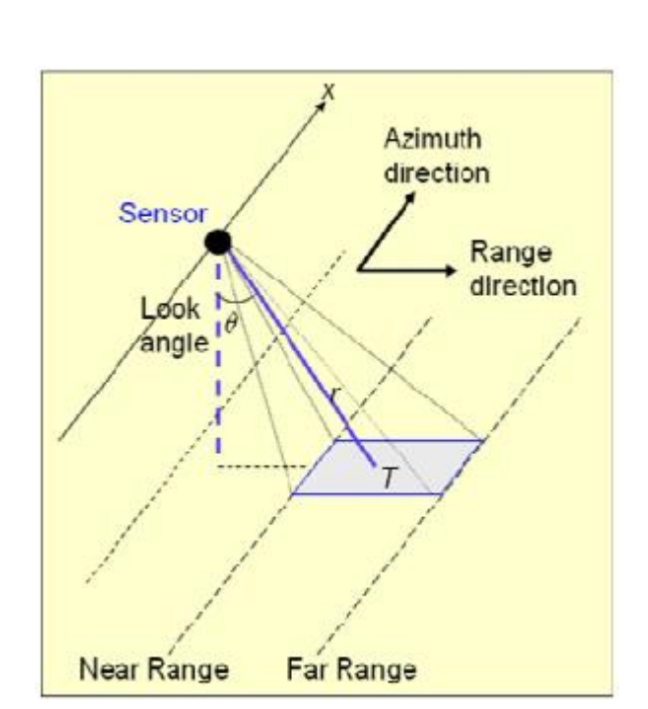

## 原始tiff图像
当作rgb图像打开

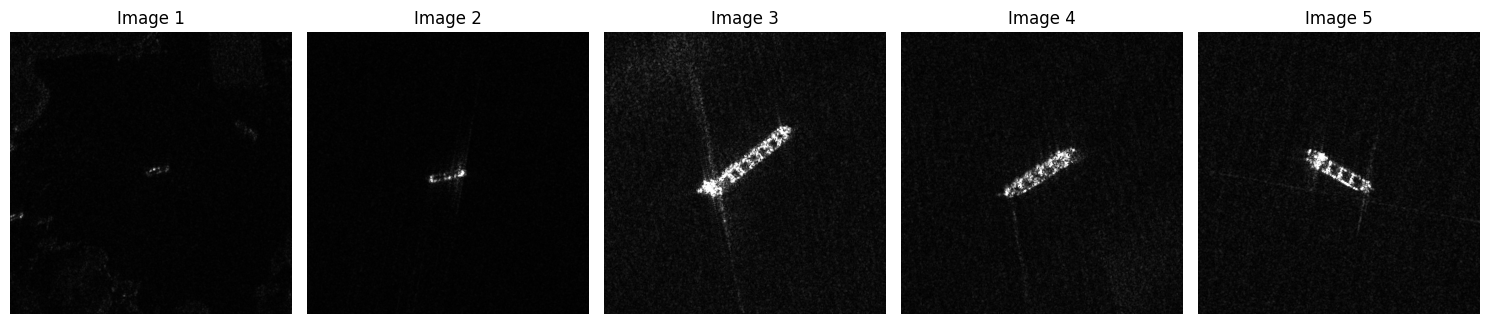

In [41]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def getpath(data_csv, idx, path_prefix="./FUSAR_ship"):
    if idx >= len(data_csv):
        print("Index out of range in data_csv")
        return None 
    path = data_csv["path"][idx].replace("\\", "/") 
    file_name = data_csv["id"][idx] + ".tiff"
    full_path = os.path.join(path_prefix, path, file_name)
    return full_path
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))  
for i in range(num_images):
    path = getpath(data_csv, i)  
    
    if path:
        try:
            # 打开图像并确保是 RGB 模式
            img = Image.open(path).convert('RGB')
            axes[i].imshow(img)
            axes[i].axis('off')  
            axes[i].set_title(f"Image {i+1}") 
        except Exception as e:
            print(f"Error opening image at index {i}: {e}")
            axes[i].axis('off')  
plt.tight_layout()
plt.show()


## 使用rastrio打开并输出tiff文件携带的参数

数据一共有 1 个波段
CRS: None
Bounds: BoundingBox(left=0.0, bottom=512.0, right=512.0, top=0.0)
Transform:
| 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|


/home/kapi/miniconda3/envs/TDL/lib/python3.10/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


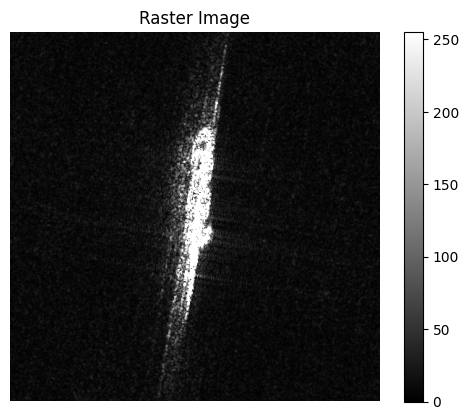

In [76]:
path = getpath(data_csv, 100)

# 使用 rasterio 打开图像
with rasterio.open(path) as dataset:
    # 获取图像的波段数
    num_bands = dataset.count
    print(f"数据一共有 {num_bands} 个波段")
    # 读取图像数据（默认读取第一个波段）
    img_data = dataset.read(1)  # 读取第一个波段的数据 
    # 获取图像的坐标参考信息（可选）
    print(f"CRS: {dataset.crs}")  # 输出坐标参考系
    print(f"Bounds: {dataset.bounds}")  # 输出图像的地理范围
    print(f"Transform:\n{dataset.transform}")  # 输出仿射变换
    # 显示图像
    plt.imshow(img_data, cmap='gray')  # 使用灰度颜色图展示
    plt.colorbar()  # 显示颜色条
    plt.title("Raster Image")
    plt.axis('off')  # 关闭坐标轴
    plt.show()


In [93]:
from osgeo import gdal
path = getpath(data_csv, 100)
# 打开 GeoTIFF 文件
dataset = gdal.Open(path)

# 获取并显示基本信息
print(f"Driver: {dataset.GetDriver().ShortName}/{dataset.GetDriver().LongName}")
print(f"Size: {dataset.RasterXSize} x {dataset.RasterYSize} pixels")
print(f"Bands: {dataset.RasterCount}")

# 获取坐标参考系统（CRS）
projection = dataset.GetProjection()
print(f"Projection: {projection}")

# 获取图像的仿射变换参数（即图像的地理坐标系统信息）
geotransform = dataset.GetGeoTransform()
if geotransform:
    print(f"GeoTransform: {geotransform}")

# 获取波段信息
for i in range(1, dataset.RasterCount + 1):
    band = dataset.GetRasterBand(i)
    print(f"Band {i} type: {gdal.GetDataTypeName(band.DataType)}")
    print(f"Band {i} min/max: {band.GetMinimum()}/{band.GetMaximum()}")

# 获取元数据（附加信息）
metadata = dataset.GetMetadata()
print(f"Metadata: {metadata}")

# 关闭数据集
dataset = None


Driver: GTiff/GeoTIFF
Size: 512 x 512 pixels
Bands: 1
Projection: 
GeoTransform: (0.0, 1.0, 0.0, 0.0, 0.0, 1.0)
Band 1 type: Byte
Band 1 min/max: None/None
Metadata: {'TIFFTAG_RESOLUTIONUNIT': '2 (pixels/inch)', 'TIFFTAG_XRESOLUTION': '72', 'TIFFTAG_YRESOLUTION': '72'}


In [98]:
def add_box(idx, data_frame=data_csv, path_prefix="./FUSAR_ship", show=True):
    """
    在第 idx 个样本上绘制船舶目标框，并并排展示原图与标注图。

    参数
    ------
    idx : int
        meta.csv 中的行索引。
    data_frame : pandas.DataFrame
        包含元数据的数据表，默认使用前面加载的 data_csv。
    path_prefix : str
        FUSAR_ship 数据集所在的根目录。
    show : bool
        是否使用 matplotlib 展示原图与带框图像。
    """
    if data_frame is None or data_frame.empty:
        raise ValueError("data_frame 为空，请先加载 meta.csv")
    if idx < 0 or idx >= len(data_frame):
        raise IndexError(f"idx {idx} 超出 data_frame 的范围")

    # 读取元数据与图像
    path = getpath(data_frame, idx, path_prefix=path_prefix)
    if path is None:
        raise FileNotFoundError(f"未找到索引 {idx} 对应的图像路径")
    if not os.path.exists(path):
        raise FileNotFoundError(f"图像不存在: {path}")

    row = data_frame.iloc[idx]
    img = Image.open(path).convert("RGB")
    width_px, height_px = img.size

    # 计算目标框尺寸（以像素为单位）
    for key in ("length", "width", "heightspace", "widthspace"):
        if pd.isna(row[key]):
            raise ValueError(f"元数据 {key} 缺失: {row['id']}")
    if row["heightspace"] <= 0 or row["widthspace"] <= 0:
        raise ValueError("像元间距必须大于 0")

    box_height = float(row["length"]) / float(row["heightspace"])
    box_width = float(row["width"]) / float(row["widthspace"])

    center_x = width_px / 2.0
    center_y = height_px / 2.0
    x0 = max(center_x - box_width / 2.0, 0)
    y0 = max(center_y - box_height / 2.0, 0)
    x1 = min(center_x + box_width / 2.0, width_px)
    y1 = min(center_y + box_height / 2.0, height_px)

    if show:
        from matplotlib.patches import Rectangle
        from matplotlib import font_manager

        preferred_fonts = ["Noto Sans CJK SC", "SimHei", "Microsoft YaHei", "WenQuanYi Zen Hei"]
        font_prop = None
        for name in preferred_fonts:
            try:
                font_path = font_manager.findfont(name, fallback_to_default=False)
            except ValueError:
                continue
            if font_path:
                font_prop = font_manager.FontProperties(fname=font_path)
                break

        if font_prop is None:
            title_raw = "Raw Image"
            title_box = "With Bounding Box"
            suptitle = f"{row['id']} | length:{row['length']}m width:{row['width']}m"
            font_kwargs = {}
        else:
            title_raw = "原始图像"
            title_box = "添加目标框"
            suptitle = f"{row['id']} | 长度:{row['length']}m 宽度:{row['width']}m"
            font_kwargs = {"fontproperties": font_prop}

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img)
        axes[0].set_title(title_raw, **font_kwargs)
        axes[0].axis("off")

        axes[1].imshow(img)
        rect = Rectangle((y0, x0), y1 - y0, x1 - x0,
                         linewidth=2, edgecolor="lime", facecolor="none")
        axes[1].add_patch(rect)
        axes[1].set_title(title_box, **font_kwargs)
        axes[1].axis("off")

        fig.suptitle(suptitle, fontsize=10, **font_kwargs)
        plt.tight_layout()
        plt.show()

    return (x0, y0, x1, y1)

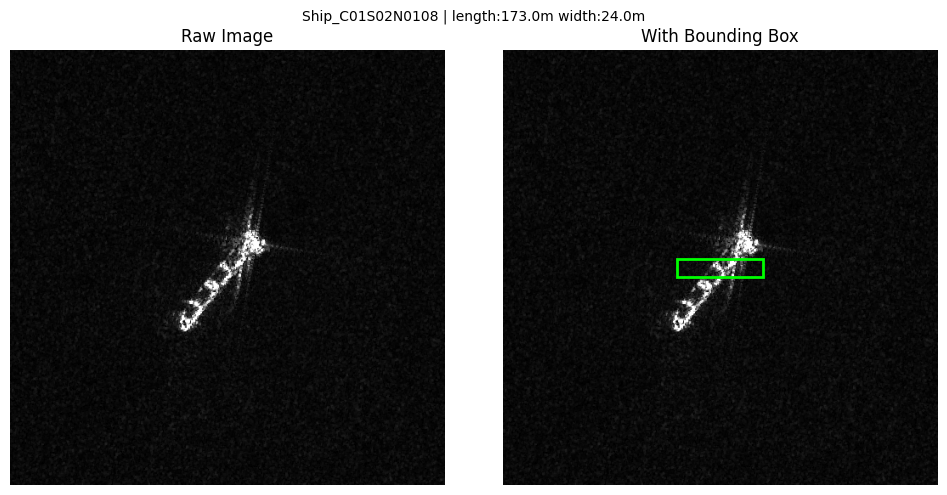

(245.32595163588687, 205.3525321391851, 266.67404836411316, 306.6474678608149)

In [100]:
# 示例：展示第 0 条数据
add_box(109)

In [ ]:
import numpy as np
import pandas as pd
import  yaml
cm=[[7337,0,1488],[0,745,190],[713,269,0]]
cm=np.array(cm)
cm_fg=cm[:-1,:-1]
with open("data.yaml","r") as f:
    data_dict = yaml.safe_load(f)
nc= data_dict['nc']
name=data_dict['names']
acc=np.array(np.zeros(nc+1))
far=np.array(np.zeros(nc+1))
rec=np.array(np.zeros(nc+1))
for i in range(nc):
    tp = np.diag(cm)[i]            # 对角 = TP
    fp = cm.sum(axis=1)[i] - np.diag(cm)[i]
    fn = cm.sum(axis=0)[i] - np.diag(cm)[i]
    acc[i] = tp / (tp + fp + 1e-9)          # 检测准确率
    far[i] = fp / (tp + fp + 1e-9)          # 虚警率
    rec[i] = tp / (tp + fn + 1e-9)          # 召回率
    print(f"类别 {name[i]} 的评估结果：")
    print(f"tp: {tp}, fp: {fp}, fn: {fn}")
    print(f"  准确率 (Precision) : {acc[i]:.4f}")
    print(f"  虚警率 (FAR)      : {far[i]:.4f}")
    print(f"  召回率 (Recall)   : {rec[i]:.4f}\n")
    #计算AP
rec[i]=0
acc[i]=1
for i in range(nc):
    ap+=(rec[i]-rec[i+1])*acc[i]
print(f"平均精确度ap:{ap}")



类别 ship 的评估结果：
tp: 7337, fp: 1488, fn: 713
  准确率 (Precision) : 0.8314
  虚警率 (FAR)      : 0.1686
  召回率 (Recall)   : 0.9114

类别 aircraft 的评估结果：
tp: 745, fp: 190, fn: 269
  准确率 (Precision) : 0.7968
  虚警率 (FAR)      : 0.2032
  召回率 (Recall)   : 0.7347

ap: 0.7577508700928997


Type of data: <class 'numpy.ndarray'>
Shape of data: (2,)
First 5 elements of data: [array([[10049.78986469, 29504.        ],
        [10049.78986469, 29503.        ],
        [10049.78986469, 29502.        ],
        ...,
        [ 6151.40227261, 29502.        ],
        [ 6151.40227261, 29503.        ],
        [ 6151.40227261, 29504.        ]], shape=(10830, 2))
 array([[10875.48548568, 29504.        ],
        [10875.48548568, 29503.        ],
        [10875.48548568, 29502.        ],
        ...,
        [10442.09545836, 29502.        ],
        [10442.09545836, 29503.        ],
        [10442.09545836, 29504.        ]], shape=(925, 2))]
First subarray shape: (10830, 2)
Second subarray shape: (925, 2)
First subarray content (first 5 rows): [[10049.78986469 29504.        ]
 [10049.78986469 29503.        ]
 [10049.78986469 29502.        ]
 [10049.78986469 29501.        ]
 [10049.78986469 29500.        ]]
Second subarray content (first 5 rows): [[10875.48548568 29504.        ]
 [1087

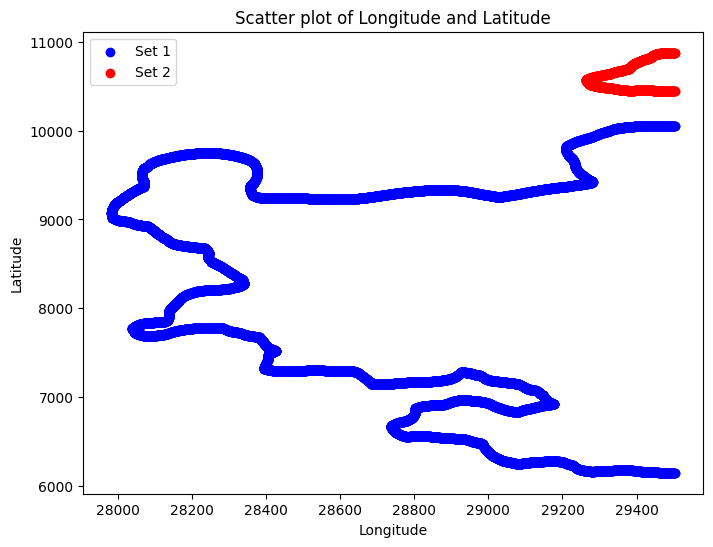

Min and Max for the first subarray: 6151.40227261351 29504.0
Min and Max for the second subarray: 10442.095458356507 29504.0


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 加载 .npy 文件
data = np.load('shoreline_train/fafc240a3e4dee41t_shoreline.npy', allow_pickle=True)

# 打印 data 的类型和形状
print("Type of data:", type(data))
print("Shape of data:", data.shape)

# 打印前 5 个元素，查看是否是嵌套的对象数组
print("First 5 elements of data:", data[:5])

# 检查 data 中的每个子数组的内容
print("First subarray shape:", data[0].shape)
print("Second subarray shape:", data[1].shape)

# 打印每个子数组的前5行内容，看看它们是否是经纬度数据
print("First subarray content (first 5 rows):", data[0][:5])
print("Second subarray content (first 5 rows):", data[1][:5])

# 假设 data[0] 和 data[1] 是经纬度坐标，提取经纬度数据
latitudes_1, longitudes_1 = data[0][:, 0], data[0][:, 1]  # 第一个子数组的经纬度
latitudes_2, longitudes_2 = data[1][:, 0], data[1][:, 1]  # 第二个子数组的经纬度

# 可视化经纬度数据
plt.figure(figsize=(8, 6))

# 绘制第一组经纬度
plt.scatter(longitudes_1, latitudes_1, c='blue', label='Set 1')

# 绘制第二组经纬度
plt.scatter(longitudes_2, latitudes_2, c='red', label='Set 2')

# 添加标签和图例
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Scatter plot of Longitude and Latitude')

# 显示图像
plt.show()

# 如果需要计算最小值和最大值：
try:
    # 打印每个子数组的最小值和最大值
    print("Min and Max for the first subarray:", np.min(data[0]), np.max(data[0]))
    print("Min and Max for the second subarray:", np.min(data[1]), np.max(data[1]))
except Exception as e:
    print("Error calculating min/max:", e)
